# Results

## Setup

Create and activate a venv inside this directory before running:

```bash
cd notebooks
python -m venv .venv
source .venv/bin/activate
pip install pandas seaborn matplotlib ipykernel
python -m ipykernel install --user --name=bza-results
```

Then select the `bza-results` kernel in Jupyter.

In [1]:
import json
import re
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
RESULTS_DIR = Path("../results")
METHODS = ["AlphaEdit", "EMMET", "MEMIT"]

# Display names for models
MODEL_LABELS = {
    "gpt2-xl": "GPT-2-XL",
    "gpt-j-6B": "GPT-J-6B",
    "Llama-3.2-3B": "LLaMA-3.2-3B",
    "llama-7b": "LLaMA-7B",
    "Mistral-7B-v0.1": "Mistral-7B",
    "Qwen2.5-7B": "Qwen2.5-7B",
    "Qwen2.5-7B-Instruct": "Qwen2.5-7B-Instruct",
    "Qwen2-7B": "Qwen2-7B",
    "internlm-7b": "InternLM-7B",
}

PRECISION_ORDER = ["FP16", "GPTQ-8", "GPTQ-4", "GPTQ-3", "GPTQ-2"]

records = []
for f in sorted(RESULTS_DIR.glob("*.json")):
    name = f.stem
    for method in METHODS:
        if f"_{method}_" not in name:
            continue
        model, rest = name.split(f"_{method}_", 1)
        m = re.fullmatch(r"(\d+)(?:-gptq(\d+))?", rest)
        if not m:
            continue
        num_edits = int(m.group(1))
        bits = int(m.group(2)) if m.group(2) else None
        precision = f"GPTQ-{bits}" if bits else "FP16"

        with open(f) as fp:
            data = json.load(fp)
        summary = data["summary"]

        records.append({
            "model": MODEL_LABELS.get(model, model),
            "method": method,
            "num_edits": num_edits,
            "bits": bits,
            "precision": precision,
            "Rewrite Accuracy": summary["rewrite_accuracy"],
            "Rephrase Accuracy": summary["rephrase_accuracy"],
            "Locality Accuracy": summary["locality_accuracy"],
        })
        break

df = pd.DataFrame(records)
df["precision"] = pd.Categorical(df["precision"], categories=PRECISION_ORDER, ordered=True)

print(f"Loaded {len(df)} result files")
df.head()

Loaded 82 result files


,model,method,num_edits,bits,precision,Rewrite Accuracy,Rephrase Accuracy,Locality Accuracy
0,LLaMA-3.2-3B,EMMET,500,2.0,GPTQ-2,0.0,0.00,20.50
1,LLaMA-3.2-3B,EMMET,500,3.0,GPTQ-3,58.0,34.05,57.64
2,LLaMA-3.2-3B,EMMET,500,4.0,GPTQ-4,93.6,59.75,59.90
3,LLaMA-3.2-3B,EMMET,500,8.0,GPTQ-8,96.4,65.65,60.64
4,LLaMA-3.2-3B,EMMET,500,NaN,FP16,96.2,65.45,60.64


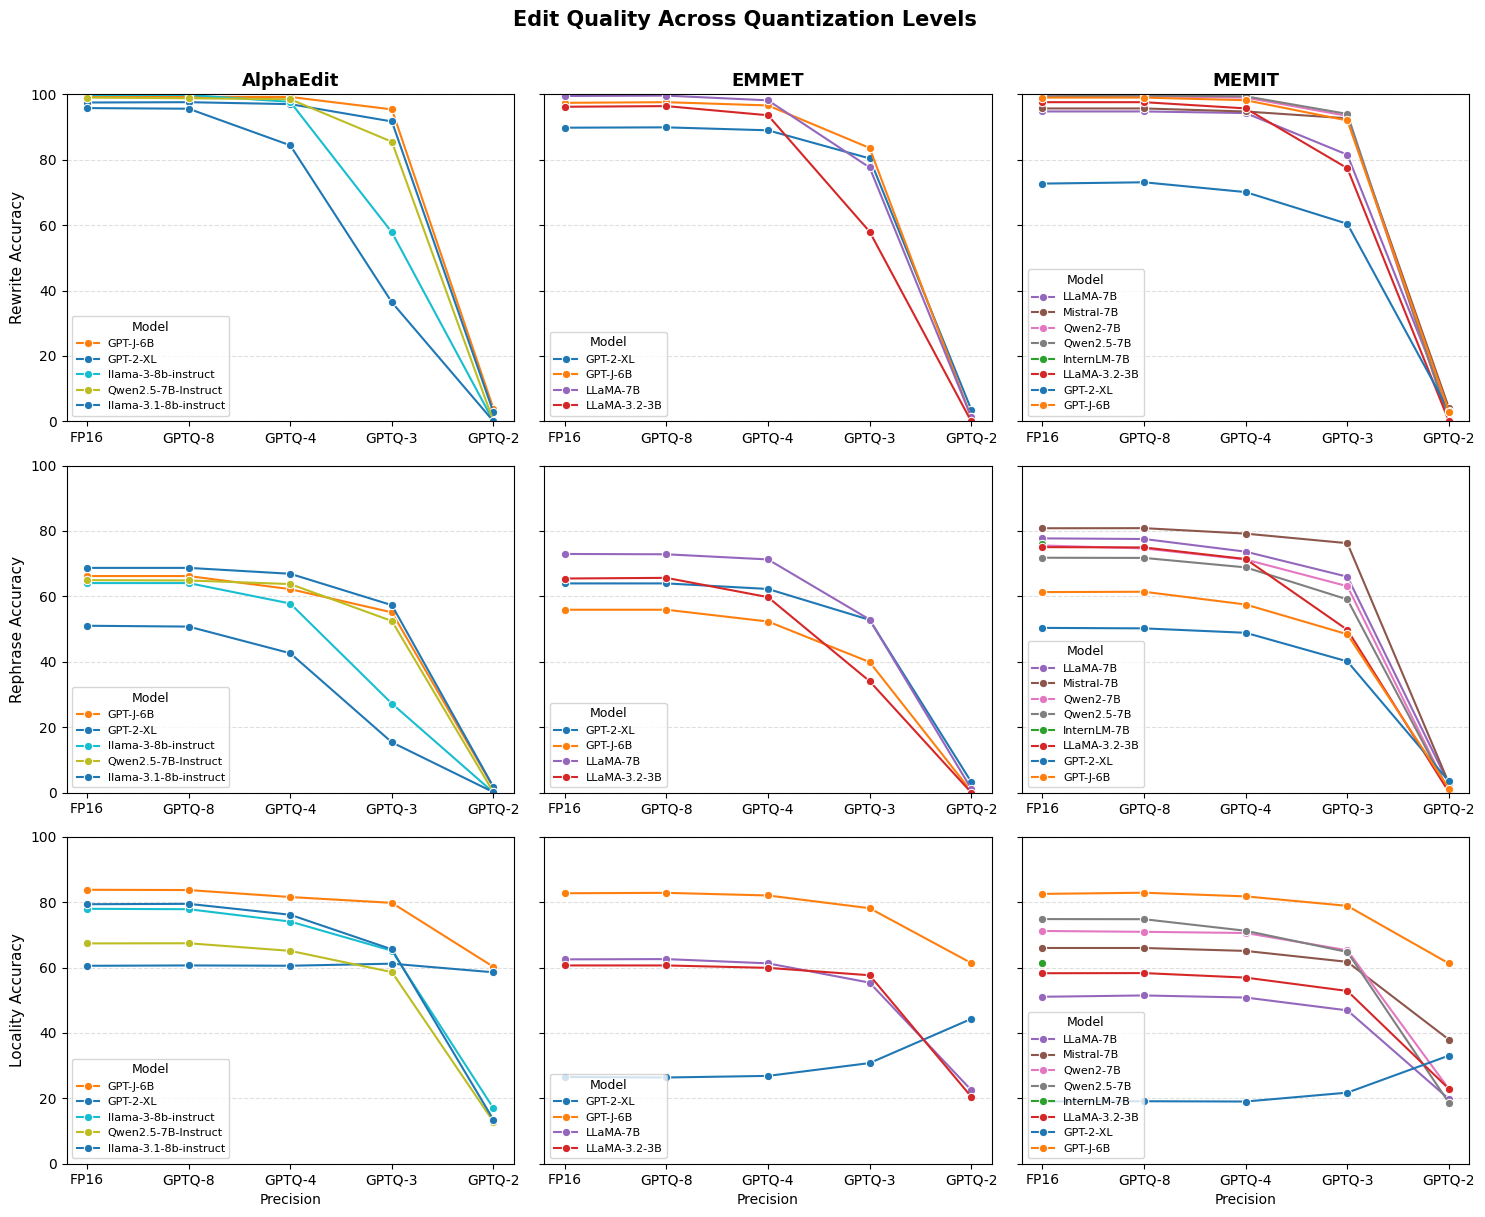

In [3]:
METRICS = ["Rewrite Accuracy", "Rephrase Accuracy", "Locality Accuracy"]

# Keep highest num_edits available per (model, method, precision)
df_best = (
    df.sort_values("num_edits", ascending=False)
    .drop_duplicates(subset=["model", "method", "precision"])
)

# Build a consistent color palette across all subplots
all_models = sorted(df_best["model"].unique())
model_palette = dict(zip(all_models, sns.color_palette("tab10", len(all_models))))

fig, axes = plt.subplots(
    nrows=len(METRICS),
    ncols=len(METHODS),
    figsize=(15, 12),
    sharey="row",
)

for row, metric in enumerate(METRICS):
    for col, method in enumerate(METHODS):
        ax = axes[row][col]
        data = df_best[df_best["method"] == method].sort_values("precision")

        sns.lineplot(
            data=data,
            x="precision",
            y=metric,
            hue="model",
            palette=model_palette,
            marker="o",
            ax=ax,
        )

        if row == 0:
            ax.set_title(method, fontsize=13, fontweight="bold")
        if col == 0:
            ax.set_ylabel(metric, fontsize=11)
        else:
            ax.set_ylabel("")
        ax.set_xlabel("Precision" if row == len(METRICS) - 1 else "")
        ax.set_ylim(0, 100)
        ax.legend(title="Model", fontsize=8, title_fontsize=9, loc="lower left")
        ax.grid(axis="y", linestyle="--", alpha=0.4)

fig.suptitle(
    "Edit Quality Across Quantization Levels",
    fontsize=15,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.savefig("../docs/figures/line_plots.pdf", dpi=300, bbox_inches="tight")
plt.show()

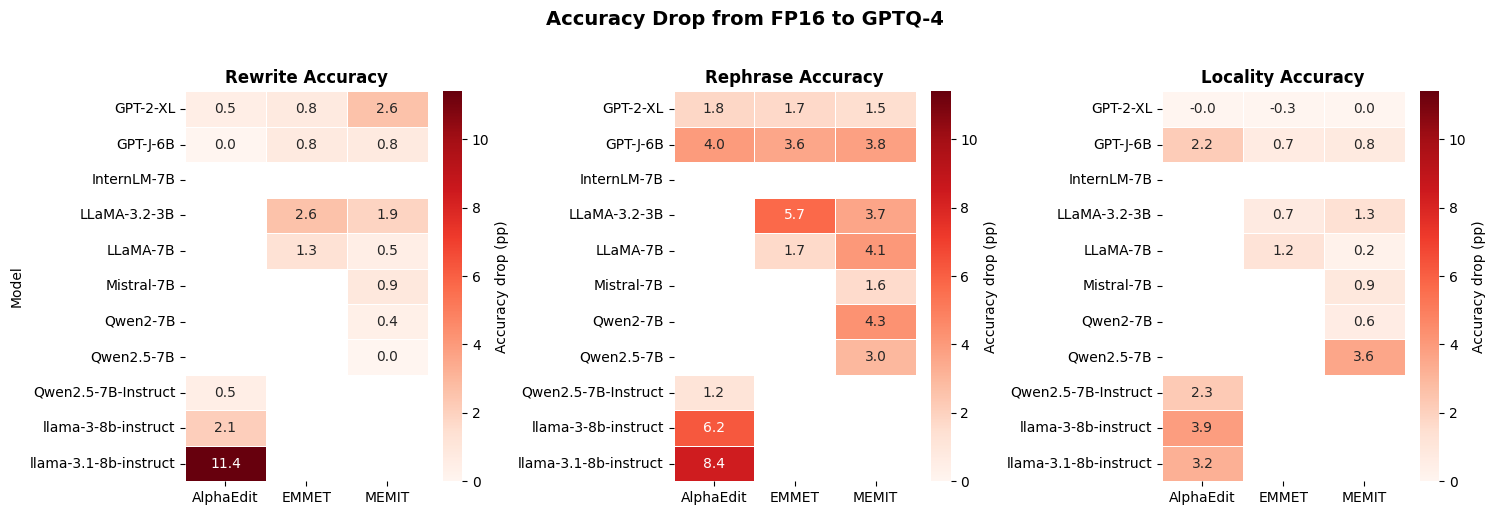

In [4]:
# Keep highest num_edits available per (model, method, precision)
df_best = (
    df.sort_values("num_edits", ascending=False)
    .drop_duplicates(subset=["model", "method", "precision"])
)

# Compute accuracy drop: FP16 - GPTQ-4, pivot to model x method for each metric
fp16  = df_best[df_best["precision"] == "FP16"].set_index(["model", "method"])
gptq4 = df_best[df_best["precision"] == "GPTQ-4"].set_index(["model", "method"])
drop  = (fp16[METRICS] - gptq4[METRICS]).reset_index()

# Shared color scale based on actual data range
vmax = drop[METRICS].max().max()

fig, axes = plt.subplots(1, len(METRICS), figsize=(15, 5))

for ax, metric in zip(axes, METRICS):
    pivot = drop.pivot(index="model", columns="method", values=metric)
    pivot = pivot.sort_index()

    sns.heatmap(
        pivot,
        ax=ax,
        annot=True,
        fmt=".1f",
        cmap="Reds",
        vmin=0,
        vmax=vmax,
        linewidths=0.5,
        cbar_kws={"label": "Accuracy drop (pp)"},
    )
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Model" if ax is axes[0] else "")

fig.suptitle(
    "Accuracy Drop from FP16 to GPTQ-4",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig("../docs/figures/heatmap_gptq4.pdf", dpi=300, bbox_inches="tight")
plt.show()